# Évaluation des résultats DiffWave

Ce notebook présente l’évaluation des deux approches mises en œuvre dans le projet :

- **From scratch** : DiffWave entraîné directement sur DODa à partir de poids initialisés aléatoirement ;
- **Fine-tuning** : DiffWave pré-entraîné sur LJSpeech puis adapté sur DODa.

L’objectif est de comparer les deux approches à partir de :

1. l’évolution des losses d’entraînement et de validation ;
2. l’écoute qualitative des audios générés ;
3. la comparaison des waveforms générées ;
4. la comparaison des spectrogrammes Mel générés ;
5. une synthèse qualitative des résultats.

Le dossier `from_scratch_10000` contient les résultats du modèle entraîné from scratch pendant 10 000 steps.  
Le dossier `fine_tuned_best` contient les résultats générés à partir du meilleur checkpoint obtenu lors du fine-tuning, sélectionné selon la loss de validation.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio, display

## 1. Définition des chemins

On définit les chemins vers les résultats des deux approches comparées.

Chaque dossier doit contenir :

- les fichiers CSV de loss ;
- les audios générés ;
- les figures produites pendant l’évaluation ;
- éventuellement les checkpoints associés.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = Path("/content/drive/MyDrive/DiffWave_Darija")

FROM_SCRATCH_DIR = PROJECT_DIR / "from_scratch_10000"
FINE_TUNED_DIR = PROJECT_DIR / "fine_tuned_best"

FIGURES_FROM_SCRATCH_DIR = FROM_SCRATCH_DIR / "figures"
FIGURES_FINE_TUNED_DIR = FINE_TUNED_DIR / "figures"

AUDIOS_FROM_SCRATCH_DIR = FROM_SCRATCH_DIR / "generated_audios"
AUDIOS_FINE_TUNED_DIR = FINE_TUNED_DIR / "generated_audios"

CSV_FROM_SCRATCH_DIR = FROM_SCRATCH_DIR / "results"
CSV_FINE_TUNED_DIR = FINE_TUNED_DIR / "results"

print("Projet :", PROJECT_DIR)
print("Résultats from scratch :", FROM_SCRATCH_DIR.exists())
print("Résultats fine-tuned :", FINE_TUNED_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Projet : /content/drive/MyDrive/DiffWave_Darija
Résultats from scratch : True
Résultats fine-tuned : True


## 2. Chargement des losses

On charge les pertes d’entraînement et de validation des deux approches.

La loss mesure l’écart entre le bruit réellement ajouté au signal audio et le bruit prédit par le modèle.  
Une loss plus faible indique que le modèle parvient mieux à apprendre la tâche de débruitage.

In [7]:
train_loss_from_scratch_path = CSV_FROM_SCRATCH_DIR / "diffwave_training_losses.csv"
val_loss_from_scratch_path = CSV_FROM_SCRATCH_DIR / "diffwave_validation_losses.csv"

train_loss_fine_tuned_path = CSV_FINE_TUNED_DIR / "diffwave_training_losses.csv"
val_loss_fine_tuned_path = CSV_FINE_TUNED_DIR / "diffwave_validation_losses.csv"

train_from_scratch = pd.read_csv(train_loss_from_scratch_path)
val_from_scratch = pd.read_csv(val_loss_from_scratch_path)

train_fine_tuned = pd.read_csv(train_loss_fine_tuned_path)
val_fine_tuned = pd.read_csv(val_loss_fine_tuned_path)

print("Train from scratch :", train_from_scratch.shape)
print("Val from scratch :", val_from_scratch.shape)
print("Train fine-tuned :", train_fine_tuned.shape)
print("Val fine-tuned :", val_fine_tuned.shape)

display(train_from_scratch.head())
display(val_from_scratch.head())
display(train_fine_tuned.head())
display(val_fine_tuned.head())

Train from scratch : (10000, 2)
Val from scratch : (4, 2)
Train fine-tuned : (10000, 2)
Val fine-tuned : (10, 2)


,step,train_loss
0,1,0.115672
1,2,0.085567
2,3,0.091990
3,4,0.087368
4,5,0.112482


,step,val_loss
0,2500,0.051580
1,5000,0.040628
2,7500,0.043805
3,10000,0.032288


,step,train_loss
0,1,2.880355
1,2,1.829675
2,3,1.781127
3,4,1.689373
4,5,1.667945


,step,val_loss
0,1000,0.073118
1,2000,0.058241
2,3000,0.066393
3,4000,0.063859
4,5000,0.041205


## 3. Comparaison des losses d’entraînement

On compare ici l’évolution de la loss d’entraînement pour les deux approches.

La comparaison doit être interprétée avec prudence, car les deux branches n’ont pas nécessairement été entraînées avec exactement les mêmes réglages, notamment en ce qui concerne le batch size. Elle reste néanmoins utile pour observer la dynamique d’apprentissage de chaque modèle.

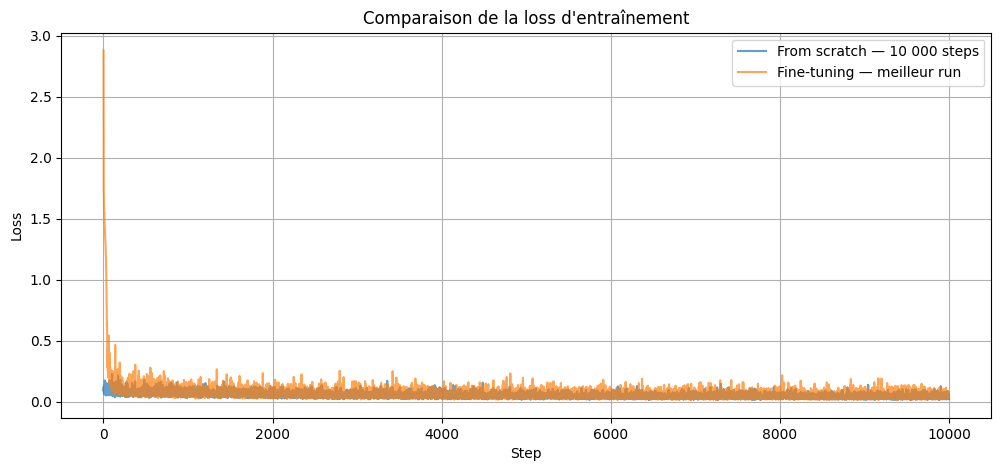

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    train_from_scratch["step"],
    train_from_scratch["train_loss"],
    label="From scratch — 10 000 steps",
    alpha=0.7
)

plt.plot(
    train_fine_tuned["step"],
    train_fine_tuned["train_loss"],
    label="Fine-tuning — meilleur run",
    alpha=0.7
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Comparaison de la loss d'entraînement")
plt.legend()
plt.grid(True)
plt.show()

## 4. Comparaison des losses de validation

La loss de validation permet d’observer la capacité de généralisation du modèle sur des données non vues pendant l’entraînement.

Pour le modèle fine-tuné, le meilleur checkpoint est celui qui minimise cette loss de validation, et non nécessairement le dernier checkpoint de l’entraînement.

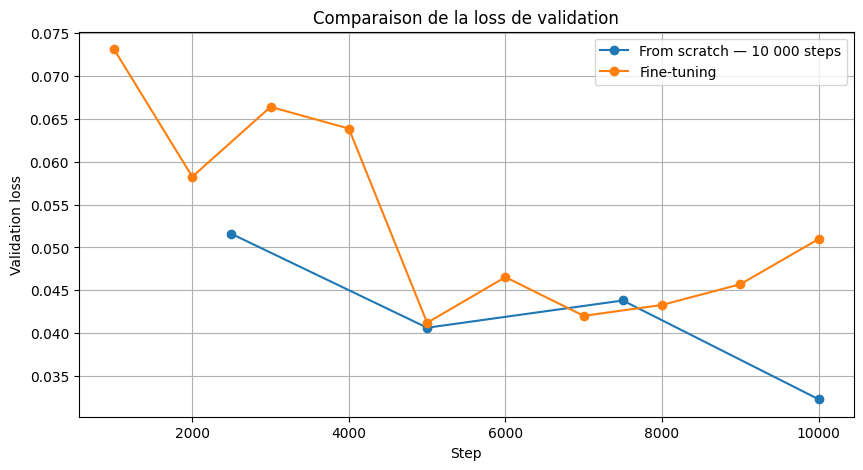

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(
    val_from_scratch["step"],
    val_from_scratch["val_loss"],
    marker="o",
    label="From scratch — 10 000 steps"
)

plt.plot(
    val_fine_tuned["step"],
    val_fine_tuned["val_loss"],
    marker="o",
    label="Fine-tuning"
)

plt.xlabel("Step")
plt.ylabel("Validation loss")
plt.title("Comparaison de la loss de validation")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
summary_loss = pd.DataFrame({
    "approche": ["From scratch", "Fine-tuning"],
    "train_loss_finale": [
        train_from_scratch["train_loss"].iloc[-1],
        train_fine_tuned["train_loss"].iloc[-1]
    ],
    "val_loss_initiale": [
        val_from_scratch["val_loss"].iloc[0],
        val_fine_tuned["val_loss"].iloc[0]
    ],
    "val_loss_finale": [
        val_from_scratch["val_loss"].iloc[-1],
        val_fine_tuned["val_loss"].iloc[-1]
    ],
    "meilleure_val_loss": [
        val_from_scratch["val_loss"].min(),
        val_fine_tuned["val_loss"].min()
    ],
    "step_meilleur_checkpoint": [
        val_from_scratch.loc[val_from_scratch["val_loss"].idxmin(), "step"],
        val_fine_tuned.loc[val_fine_tuned["val_loss"].idxmin(), "step"]
    ]
})

display(summary_loss)

,approche,train_loss_finale,val_loss_initiale,val_loss_finale,meilleure_val_loss,step_meilleur_checkpoint
0,From scratch,0.021924,0.051580,0.032288,0.032288,10000
1,Fine-tuning,0.042995,0.073118,0.050965,0.041205,5000


### Interprétation des losses

Les deux approches permettent au modèle d’apprendre la tâche de débruitage.  
Le modèle fine-tuné converge rapidement grâce aux poids pré-entraînés chargés depuis LJSpeech, tandis que le modèle from scratch apprend uniquement à partir du corpus DODa.

La comparaison des meilleures losses de validation permet d’identifier quelle approche généralise le mieux dans nos conditions expérimentales. Cette comparaison doit cependant être nuancée, car les deux branches n’ont pas été entraînées avec exactement les mêmes hyperparamètres.

## 5. Écoute des audios générés

On compare maintenant quelques audios générés par les deux approches.  
Les fichiers doivent correspondre aux mêmes exemples du jeu de test afin que la comparaison soit cohérente.

In [11]:
audios_from_scratch = sorted(list(AUDIOS_FROM_SCRATCH_DIR.glob("*.wav")))
audios_fine_tuned = sorted(list(AUDIOS_FINE_TUNED_DIR.glob("*.wav")))

print("Audios from scratch :", len(audios_from_scratch))
print("Audios fine-tuned :", len(audios_fine_tuned))

print("\nExemples from scratch :")
for p in audios_from_scratch[:5]:
    print(p.name)

print("\nExemples fine-tuned :")
for p in audios_fine_tuned[:5]:
    print(p.name)

Audios from scratch : 4
Audios fine-tuned : 6

Exemples from scratch :
generated_03633.wav
generated_03757.wav
generated_tensor(3757).wav
prediction.wav

Exemples fine-tuned :
generated_03633.wav
generated_03757.wav
generated_04938.wav
generated_10384.wav
generated_11678.wav


In [12]:
N_EXAMPLES = min(3, len(audios_from_scratch), len(audios_fine_tuned))

for i in range(N_EXAMPLES):
    print("=" * 80)
    print(f"Exemple {i + 1}")

    print("\nFrom scratch :", audios_from_scratch[i].name)
    display(Audio(str(audios_from_scratch[i])))

    print("\nFine-tuned :", audios_fine_tuned[i].name)
    display(Audio(str(audios_fine_tuned[i])))

Exemple 1

From scratch : generated_03633.wav



Fine-tuned : generated_03633.wav


Exemple 2

From scratch : generated_03757.wav



Fine-tuned : generated_03757.wav


Exemple 3

From scratch : generated_tensor(3757).wav



Fine-tuned : generated_04938.wav


## 6. Comparaison visuelle des waveforms générées

La waveform permet de comparer la structure temporelle du signal généré par les deux approches.

Une waveform plus proche de la structure vocale attendue présente généralement des zones d’activité bien localisées ainsi que des zones plus calmes correspondant aux silences ou aux faibles énergies.

In [13]:
def load_audio(path):
    audio, sr = sf.read(path)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    return audio.astype(np.float32), sr


def plot_waveform_comparison(audio_from_scratch_path, audio_fine_tuned_path):
    audio_from_scratch, sr_from_scratch = load_audio(audio_from_scratch_path)
    audio_fine_tuned, sr_fine_tuned = load_audio(audio_fine_tuned_path)

    plt.figure(figsize=(14, 5))
    plt.plot(audio_from_scratch, label="From scratch", alpha=0.7)
    plt.plot(audio_fine_tuned, label="Fine-tuned", alpha=0.7)
    plt.xlabel("Échantillons")
    plt.ylabel("Amplitude")
    plt.title("Comparaison des waveforms générées")
    plt.legend()
    plt.grid(True)
    plt.show()

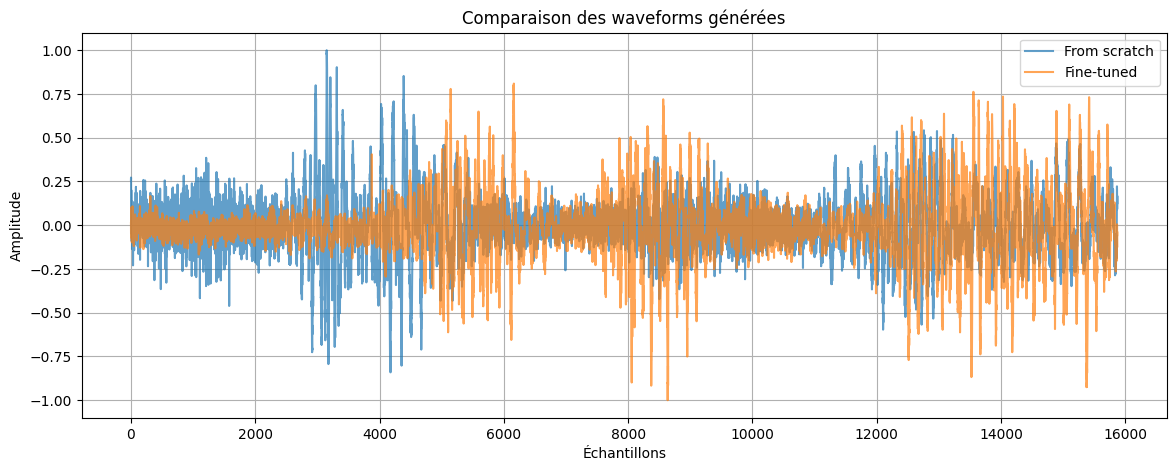

In [14]:
if len(audios_from_scratch) > 0 and len(audios_fine_tuned) > 0:
    plot_waveform_comparison(audios_from_scratch[0], audios_fine_tuned[0])
else:
    print("Aucun audio disponible pour la comparaison.")

## 7. Comparaison des spectrogrammes Mel générés

Les spectrogrammes Mel permettent d’observer la structure temps-fréquence des audios générés.

Un spectrogramme plus structuré, avec des zones d’énergie cohérentes et moins diffuses, indique généralement que le modèle reconstruit mieux certaines caractéristiques de la parole.

In [15]:
SAMPLE_RATE = 22050
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 80

def compute_log_mel(audio, sr=SAMPLE_RATE):
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        n_mels=N_MELS,
        power=1.0
    )
    mel_log = np.log(np.clip(mel, 1e-5, None))
    mel_log = np.clip(mel_log, -11.5, None)
    return mel_log


def plot_mel_comparison(audio_from_scratch_path, audio_fine_tuned_path):
    audio_from_scratch, sr_from_scratch = load_audio(audio_from_scratch_path)
    audio_fine_tuned, sr_fine_tuned = load_audio(audio_fine_tuned_path)

    mel_from_scratch = compute_log_mel(audio_from_scratch, sr_from_scratch)
    mel_fine_tuned = compute_log_mel(audio_fine_tuned, sr_fine_tuned)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    librosa.display.specshow(
        mel_from_scratch,
        sr=sr_from_scratch,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=axes[0]
    )
    axes[0].set_title("Mel généré — from scratch")

    librosa.display.specshow(
        mel_fine_tuned,
        sr=sr_fine_tuned,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=axes[1]
    )
    axes[1].set_title("Mel généré — fine-tuning")

    plt.tight_layout()
    plt.show()

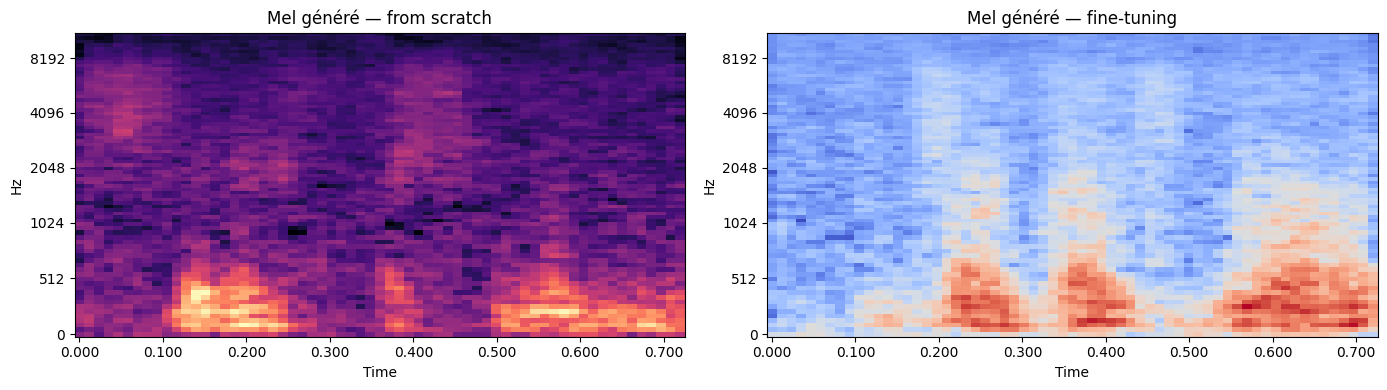

In [16]:
if len(audios_from_scratch) > 0 and len(audios_fine_tuned) > 0:
    plot_mel_comparison(audios_from_scratch[0], audios_fine_tuned[0])
else:
    print("Aucun audio disponible pour la comparaison Mel.")

## 8. Évaluation qualitative

On construit un tableau simple pour formaliser l’analyse qualitative des audios générés.

Les critères proposés sont :

- qualité sonore générale ;
- niveau de bruit ;
- présence d’une structure vocale ;
- stabilité du signal ;
- commentaire libre.

Cette évaluation reste exploratoire, mais elle permet de comparer les deux approches de manière organisée.

In [17]:
evaluation_rows = []

n = min(len(audios_from_scratch), len(audios_fine_tuned), 5)

for i in range(n):
    evaluation_rows.append({
        "example": i + 1,
        "audio_from_scratch": audios_from_scratch[i].name,
        "audio_fine_tuned": audios_fine_tuned[i].name,
        "quality_from_scratch_1_to_5": None,
        "quality_fine_tuned_1_to_5": None,
        "noise_from_scratch_1_to_5": None,
        "noise_fine_tuned_1_to_5": None,
        "comments": None
    })

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)

evaluation_path = PROJECT_DIR / "evaluation_comparison_from_scratch_vs_fine_tuned.csv"
evaluation_df.to_csv(evaluation_path, index=False)

print("Tableau d'évaluation sauvegardé :", evaluation_path)

,example,audio_from_scratch,audio_fine_tuned,quality_from_scratch_1_to_5,quality_fine_tuned_1_to_5,noise_from_scratch_1_to_5,noise_fine_tuned_1_to_5,comments
0,1,generated_03633.wav,generated_03633.wav,None,None,None,None,None
1,2,generated_03757.wav,generated_03757.wav,None,None,None,None,None
2,3,generated_tensor(3757).wav,generated_04938.wav,None,None,None,None,None
3,4,prediction.wav,generated_10384.wav,None,None,None,None,None


Tableau d'évaluation sauvegardé : /content/drive/MyDrive/DiffWave_Darija/evaluation_comparison_from_scratch_vs_fine_tuned.csv


## 9. Synthèse des résultats

La comparaison entre l’entraînement **from scratch** et le **fine-tuning** permet d’évaluer l’intérêt du transfert d’apprentissage dans notre configuration expérimentale.

Le modèle fine-tuné bénéficie d’une initialisation issue d’un modèle pré-entraîné sur **LJSpeech**, tandis que le modèle from scratch apprend uniquement à partir du corpus **DODa**. Dans nos résultats, le fine-tuning ne conduit pas nécessairement à une amélioration nette par rapport au modèle entraîné from scratch.

Plusieurs éléments peuvent expliquer ce résultat :

- le modèle pré-entraîné a été appris sur **LJSpeech**, un corpus anglais d’environ **24 heures**, alors que notre adaptation porte sur un corpus Darija masculin d’environ **6 heures** ;
- le modèle DiffWave de référence a été entraîné beaucoup plus longtemps, jusqu’à **1 million de steps**, alors que notre fine-tuning a été limité à **10 000 steps** ;
- la distance linguistique entre l’anglais et le Darija est importante, ce qui peut réduire l’intérêt du transfert pour certaines caractéristiques phonétiques propres à la langue cible ;
- enfin, les deux branches n’ont pas été entraînées avec exactement les mêmes hyperparamètres, notamment le batch size, ce qui limite la portée d’une comparaison strictement quantitative.

Ainsi, le fine-tuning reste une approche pertinente, mais nos expériences montrent que son bénéfice n’est pas automatique dans un contexte de langue peu dotée et avec un budget d’entraînement réduit.